In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def show(img, title='', cmap=None, size=(12,7)):
    plt.figure(figsize=size)
    if img.ndim == 3:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap or 'gray')
    plt.title(title); plt.axis('off'); plt.show()

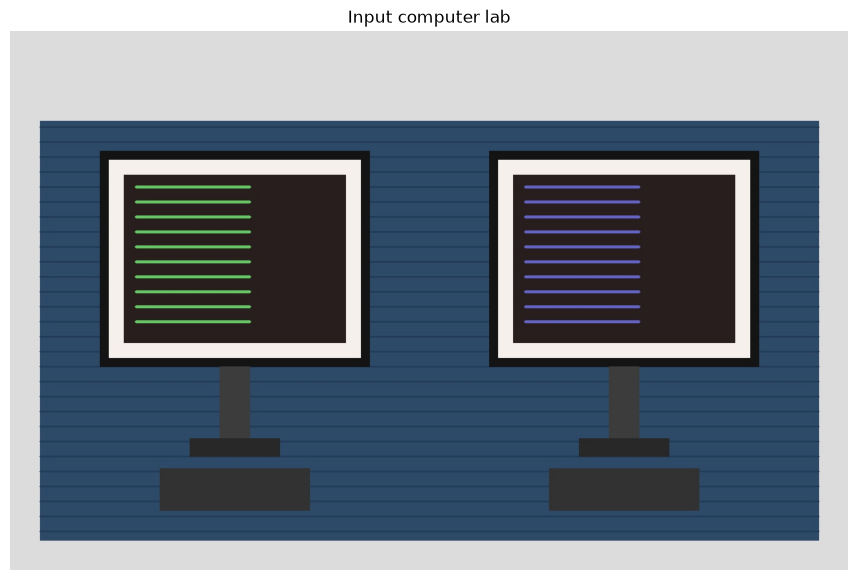

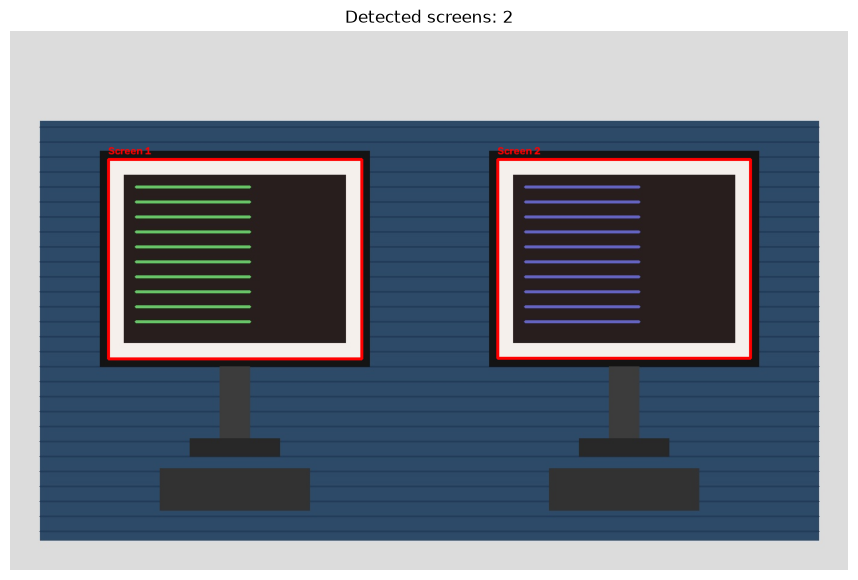

Screen count: 2


In [3]:
IMAGE_PATH = 'computer_lab.jpg'   
img = cv.imread(IMAGE_PATH)
if img is None:
    raise FileNotFoundError(f"Add a computer-lab image at: {IMAGE_PATH}")
show(img, 'Input computer lab')

# ============================================================
# TASK 1: Monitor / Screen Detection
# ============================================================

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
blur = cv.GaussianBlur(gray, (5, 5), 1.2)
edges = cv.Canny(blur, 60, 160)

lines = cv.HoughLinesP(
    edges,
    1,
    np.pi / 180,
    threshold=65,
    minLineLength=50,
    maxLineGap=18
)

line_view = img.copy()
accepted = []

H, W = gray.shape

if lines is not None:
    lines = lines.reshape(-1, 4)

    for x1, y1, x2, y2 in lines:
        angle = abs(
            np.degrees(
                np.arctan2(y2 - y1, x2 - x1)
            )
        )

        if (
            max(x1, x2) <= 15
            or min(x1, x2) >= W - 15
            or max(y1, y2) <= 15
            or min(y1, y2) >= H - 15
        ):
            continue

        if angle < 12 or angle > 78:
            accepted.append((x1, y1, x2, y2))

            cv.line(
                line_view,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

closed = cv.morphologyEx(
    edges,
    cv.MORPH_CLOSE,
    np.ones((5, 5), np.uint8),
    iterations=1
)

contours, _ = cv.findContours(
    closed,
    cv.RETR_LIST,
    cv.CHAIN_APPROX_SIMPLE
)

result = img.copy()
screens = []
image_area = H * W

for c in contours:
    x, y, w, h = cv.boundingRect(c)

    area_ratio = (w * h) / float(image_area)
    aspect = w / float(max(h, 1))

    if w < 100 or h < 80:
        continue

    if not 0.025 <= area_ratio <= 0.25:
        continue

    if not 1.15 <= aspect <= 2.0:
        continue

    if (
        x <= 15
        or y <= 15
        or x + w >= W - 15
        or y + h >= H - 15
    ):
        continue

    perimeter = cv.arcLength(c, True)
    approx = cv.approxPolyDP(
        c,
        0.02 * perimeter,
        True
    )

    if 4 <= len(approx) <= 6:
        screens.append((x, y, w, h))


def iou(r1, r2):
    x1, y1, w1, h1 = r1
    x2, y2, w2, h2 = r2

    xa = max(x1, x2)
    ya = max(y1, y2)
    xb = min(x1 + w1, x2 + w2)
    yb = min(y1 + h1, y2 + h2)

    if xb <= xa or yb <= ya:
        return 0.0

    intersection = (xb - xa) * (yb - ya)

    return intersection / float(
        w1 * h1 + w2 * h2 - intersection
    )


screens = sorted(
    screens,
    key=lambda r: r[2] * r[3],
    reverse=True
)

unique_screens = []

for candidate in screens:
    duplicate = False

    cx = candidate[0] + candidate[2] / 2
    cy = candidate[1] + candidate[3] / 2

    for existing in unique_screens:
        ex = existing[0] + existing[2] / 2
        ey = existing[1] + existing[3] / 2

        distance = np.hypot(
            cx - ex,
            cy - ey
        )

        if (
            iou(candidate, existing) > 0.45
            or distance < 30
        ):
            duplicate = True
            break

    if not duplicate:
        unique_screens.append(candidate)

screens = sorted(
    unique_screens,
    key=lambda r: r[0]
)

for i, (x, y, w, h) in enumerate(screens, 1):
    cv.rectangle(
        result,
        (x, y),
        (x + w, y + h),
        (0, 0, 255),
        3
    )

    cv.putText(
        result,
        f"Screen {i}",
        (x, max(20, y - 8)),
        cv.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 0, 255),
        2
    )

show(result, f"Detected screens: {len(screens)}")

cv.imwrite(
    "task1_screen_detection.jpg",
    result
)

print("Screen count:", len(screens))


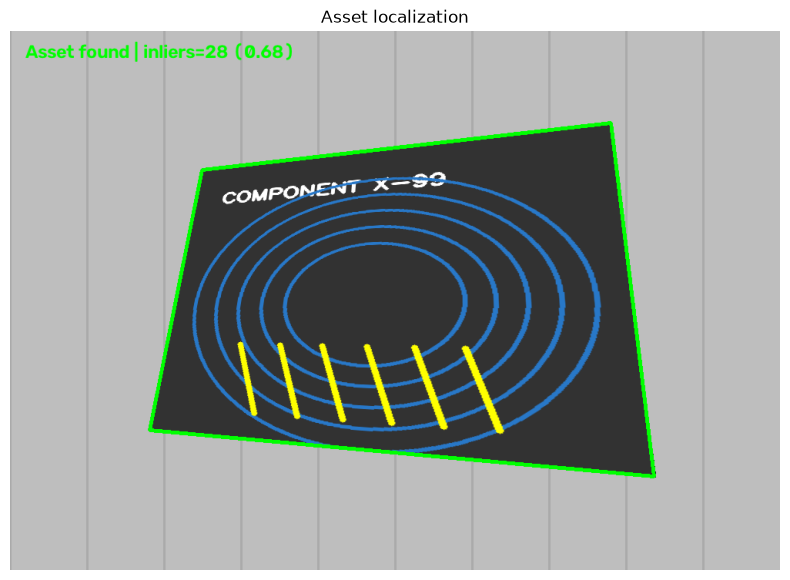

Good SIFT matches: 41


In [5]:
# ============================================================
# TASK 2: SIFT Asset Localization
# ============================================================

REFERENCE_PATH = 'box.png'
SCENE_PATH = 'box_in_scene.png'

ref = cv.imread(REFERENCE_PATH)
scene = cv.imread(SCENE_PATH)

if ref is None:
    raise FileNotFoundError(
        f"Reference image not found: {REFERENCE_PATH}"
    )

if scene is None:
    raise FileNotFoundError(
        f"Scene image not found: {SCENE_PATH}"
    )

sift = cv.SIFT_create(nfeatures=2500)

gray_ref = cv.cvtColor(
    ref,
    cv.COLOR_BGR2GRAY
)

gray_scene = cv.cvtColor(
    scene,
    cv.COLOR_BGR2GRAY
)

kp1, des1 = sift.detectAndCompute(
    gray_ref,
    None
)

kp2, des2 = sift.detectAndCompute(
    gray_scene,
    None
)

if des1 is None or des2 is None:
    raise RuntimeError(
        "Not enough texture for SIFT descriptors."
    )

flann = cv.FlannBasedMatcher(
    dict(
        algorithm=1,
        trees=5
    ),
    dict(
        checks=80
    )
)

knn = flann.knnMatch(
    des1,
    des2,
    k=2
)

good = []

for pair in knn:
    if len(pair) < 2:
        continue

    m, n = pair

    if m.distance < 0.72 * n.distance:
        good.append(m)

result = scene.copy()

if len(good) >= 10:

    src = np.float32([
        kp1[m.queryIdx].pt
        for m in good
    ]).reshape(-1, 1, 2)

    dst = np.float32([
        kp2[m.trainIdx].pt
        for m in good
    ]).reshape(-1, 1, 2)

    H, inliers = cv.findHomography(
        src,
        dst,
        cv.RANSAC,
        5.0
    )

    if H is not None and inliers is not None:

        mask = inliers.ravel().astype(bool)
        inlier_count = int(mask.sum())
        ratio = inlier_count / float(len(good))

        if inlier_count >= 8 and ratio >= 0.35:

            h, w = ref.shape[:2]

            box = np.float32([
                [0, 0],
                [w - 1, 0],
                [w - 1, h - 1],
                [0, h - 1]
            ]).reshape(-1, 1, 2)

            projected = cv.perspectiveTransform(
                box,
                H
            ).astype(np.int32)

            cv.polylines(
                result,
                [projected],
                True,
                (0, 255, 0),
                4
            )

            cv.putText(
                result,
                f"Asset found | inliers={inlier_count} ({ratio:.2f})",
                (20, 35),
                cv.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 0),
                2
            )

        else:
            cv.putText(
                result,
                "Asset not found: weak homography",
                (20, 35),
                cv.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 0, 255),
                2
            )

    else:
        cv.putText(
            result,
            "Homography failed",
            (20, 35),
            cv.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 255),
            2
        )

else:
    cv.putText(
        result,
        "Asset not found: insufficient matches",
        (20, 35),
        cv.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 0, 255),
        2
    )

show(result, "Asset localization")

cv.imwrite(
    "task2_asset_tracking.jpg",
    result
)

print("Good SIFT matches:", len(good))


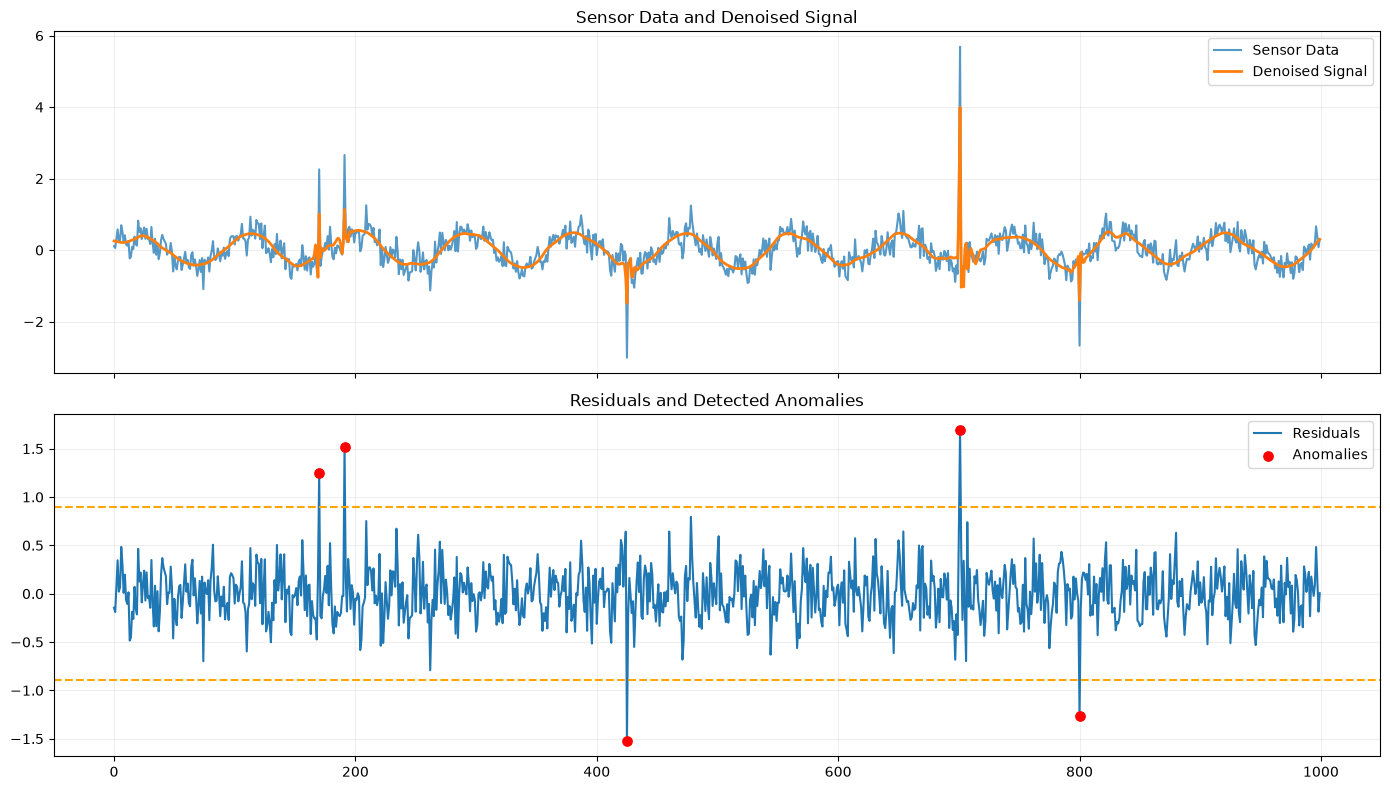

Detected anomaly indices: [170, 191, 425, 701, 800]


In [6]:
# ============================================================
# TASK 3: Wavelet Denoising + Anomaly Detection
# ============================================================

import pywt

np.random.seed(42)

N = 1000
t = np.arange(N)

signal = (
    0.45 * np.sin(2 * np.pi * t / 90)
    + 0.18 * np.sin(2 * np.pi * t / 19)
    + 0.22 * np.random.randn(N)
)

true_anomalies = np.array([
    170, 191, 425, 700, 701, 800
])

signal[true_anomalies] += np.array([
    2.8, 2.1, -3.0, 2.5, 6.0, -2.7
])

wavelet = 'db4'
level = 4

coeffs = pywt.wavedec(
    signal,
    wavelet,
    level=level
)

sigma = (
    np.median(np.abs(coeffs[-1]))
    / 0.6745
)

threshold = (
    sigma
    * np.sqrt(2 * np.log(len(signal)))
)

denoised_coeffs = [
    coeffs[0]
]

denoised_coeffs += [
    pywt.threshold(
        c,
        threshold,
        mode='soft'
    )
    for c in coeffs[1:]
]

denoised = pywt.waverec(
    denoised_coeffs,
    wavelet
)[:len(signal)]

residual = signal - denoised

residual_median = np.median(residual)

mad = np.median(
    np.abs(
        residual - residual_median
    )
)

robust_sigma = 1.4826 * mad
anomaly_threshold = 3.5 * robust_sigma

anomaly_mask = (
    np.abs(
        residual - residual_median
    )
    > anomaly_threshold
)

idx = np.where(
    anomaly_mask
)[0]

fig, ax = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True
)

ax[0].plot(
    signal,
    label='Sensor Data',
    alpha=0.75
)

ax[0].plot(
    denoised,
    label='Denoised Signal',
    linewidth=2
)

ax[0].set_title(
    'Sensor Data and Denoised Signal'
)

ax[0].legend()
ax[0].grid(alpha=0.2)

ax[1].plot(
    residual,
    label='Residuals'
)

ax[1].scatter(
    idx,
    residual[idx],
    color='red',
    s=45,
    label='Anomalies',
    zorder=3
)

ax[1].axhline(
    anomaly_threshold,
    color='orange',
    linestyle='--'
)

ax[1].axhline(
    -anomaly_threshold,
    color='orange',
    linestyle='--'
)

ax[1].set_title(
    'Residuals and Detected Anomalies'
)

ax[1].legend()
ax[1].grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    'task3_wavelet_anomalies.png',
    dpi=180
)

plt.show()

print(
    "Detected anomaly indices:",
    idx.tolist()
)


In [7]:
# ============================================================
# TASK 4: Video Object Recognition
# ============================================================

REFERENCE_PATH = 'object.png'
VIDEO_PATH = 'object_video.mp4'
OUTPUT_PATH = 'task4_recognized.mp4'

ref = cv.imread(REFERENCE_PATH)
cap = cv.VideoCapture(VIDEO_PATH)

if ref is None:
    raise FileNotFoundError(
        f"Reference image not found: {REFERENCE_PATH}"
    )

if not cap.isOpened():
    raise FileNotFoundError(
        f"Video could not be opened: {VIDEO_PATH}"
    )

sift = cv.SIFT_create(
    nfeatures=1800
)

gref = cv.cvtColor(
    ref,
    cv.COLOR_BGR2GRAY
)

kp1, des1 = sift.detectAndCompute(
    gref,
    None
)

if des1 is None or len(kp1) < 4:
    raise RuntimeError(
        "Not enough SIFT features in reference object."
    )

fps = cap.get(
    cv.CAP_PROP_FPS
) or 25

W = int(
    cap.get(cv.CAP_PROP_FRAME_WIDTH)
)

H = int(
    cap.get(cv.CAP_PROP_FRAME_HEIGHT)
)

out = cv.VideoWriter(
    OUTPUT_PATH,
    cv.VideoWriter_fourcc(*'mp4v'),
    fps,
    (W, H)
)

flann = cv.FlannBasedMatcher(
    dict(
        algorithm=1,
        trees=5
    ),
    dict(
        checks=60
    )
)

detected_frames = 0
frame_count = 0

try:

    while True:

        ok, frame = cap.read()

        if not ok:
            break

        frame_count += 1

        gray_frame = cv.cvtColor(
            frame,
            cv.COLOR_BGR2GRAY
        )

        kp2, des2 = sift.detectAndCompute(
            gray_frame,
            None
        )

        if des2 is not None:

            pairs = flann.knnMatch(
                des1,
                des2,
                k=2
            )

            good = []

            for pair in pairs:

                if len(pair) < 2:
                    continue

                m, n = pair

                if m.distance < 0.72 * n.distance:
                    good.append(m)

            if len(good) >= 10:

                src = np.float32([
                    kp1[m.queryIdx].pt
                    for m in good
                ]).reshape(-1, 1, 2)

                dst = np.float32([
                    kp2[m.trainIdx].pt
                    for m in good
                ]).reshape(-1, 1, 2)

                M, inliers = cv.findHomography(
                    src,
                    dst,
                    cv.RANSAC,
                    5.0
                )

                if M is not None and inliers is not None:

                    inlier_count = int(
                        inliers.sum()
                    )

                    if inlier_count >= 8:

                        h, w = ref.shape[:2]

                        box = np.float32([
                            [0, 0],
                            [w - 1, 0],
                            [w - 1, h - 1],
                            [0, h - 1]
                        ]).reshape(-1, 1, 2)

                        poly = cv.perspectiveTransform(
                            box,
                            M
                        ).astype(np.int32)

                        cv.polylines(
                            frame,
                            [poly],
                            True,
                            (0, 255, 0),
                            4
                        )

                        cv.putText(
                            frame,
                            'OBJECT RECOGNIZED',
                            (20, 40),
                            cv.FONT_HERSHEY_SIMPLEX,
                            1,
                            (0, 255, 0),
                            3
                        )

                        detected_frames += 1

        out.write(frame)

finally:

    cap.release()
    out.release()

print(
    f"Saved {OUTPUT_PATH}; "
    f"recognized in {detected_frames}/{frame_count} frames"
)


Saved task4_recognized.mp4; recognized in 75/75 frames


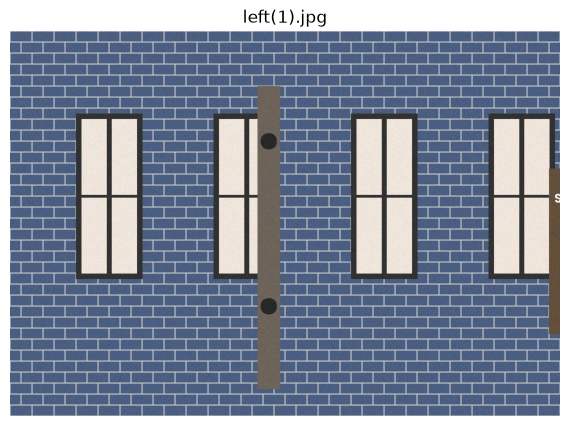

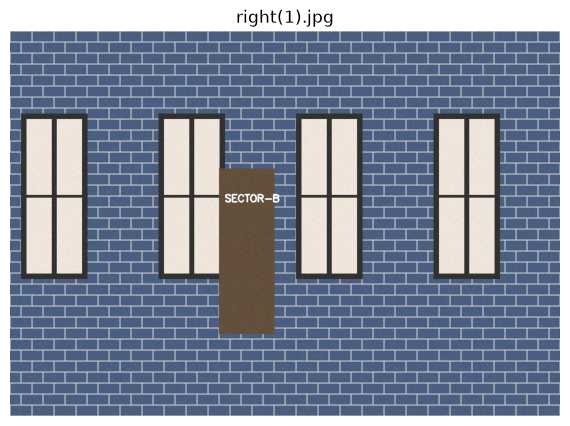

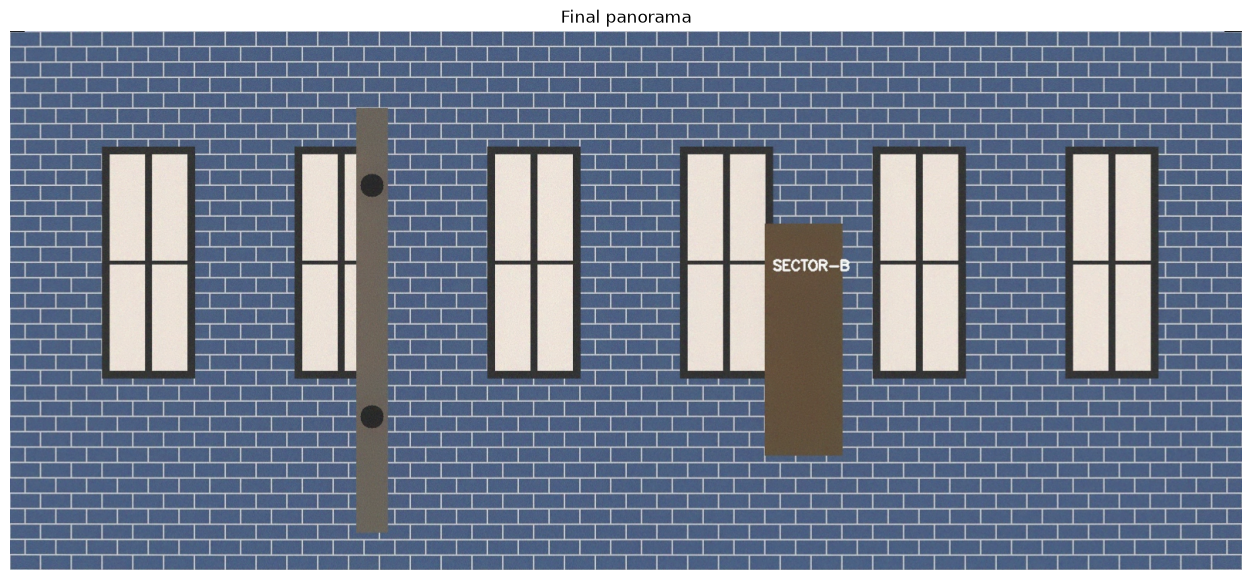

Saved task5_panorama.jpg (699, 1598, 3)


In [8]:
# ============================================================
# TASK 5: Panorama Stitching
# ============================================================

IMAGE_PATHS = [
    'left(1).jpg',
    'right(1).jpg'
]

images = [
    cv.imread(path)
    for path in IMAGE_PATHS
]

for path, image in zip(
    IMAGE_PATHS,
    images
):

    if image is None:
        raise FileNotFoundError(
            f"Image not found: {path}"
        )

for path, image in zip(
    IMAGE_PATHS,
    images
):

    show(
        image,
        path,
        size=(8, 5)
    )

stitcher = cv.Stitcher_create(
    cv.Stitcher_PANORAMA
)

status, pano = stitcher.stitch(
    images
)

if status != cv.Stitcher_OK:
    raise RuntimeError(
        f"Stitching failed with status {status}. "
        "Ensure 30-50% overlap and textured content."
    )

gray_pano = cv.cvtColor(
    pano,
    cv.COLOR_BGR2GRAY
)

_, mask = cv.threshold(
    gray_pano,
    1,
    255,
    cv.THRESH_BINARY
)

nonzero = cv.findNonZero(mask)

if nonzero is None:
    raise RuntimeError(
        "Panorama contains no valid pixels."
    )

x, y, w, h = cv.boundingRect(
    nonzero
)

cropped = pano[
    y:y + h,
    x:x + w
]

show(
    cropped,
    'Final panorama',
    size=(18, 7)
)

cv.imwrite(
    'task5_panorama.jpg',
    cropped
)

print(
    'Saved task5_panorama.jpg',
    cropped.shape
)


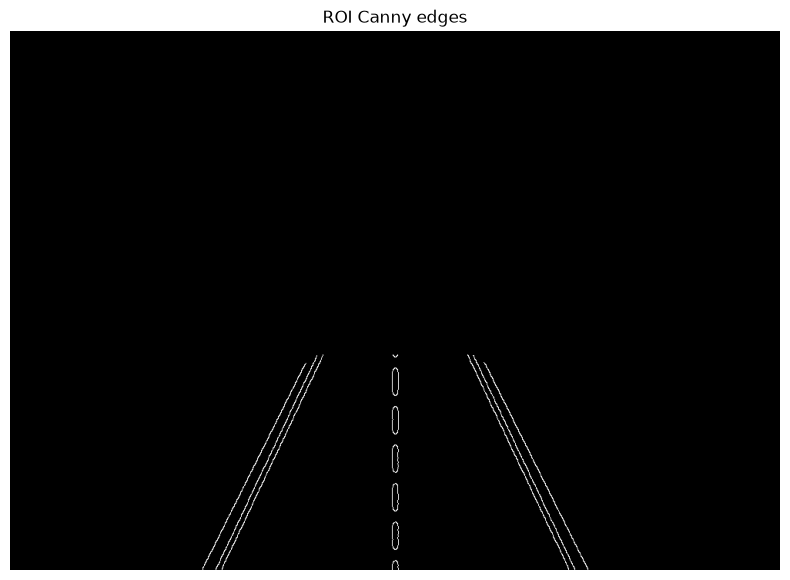

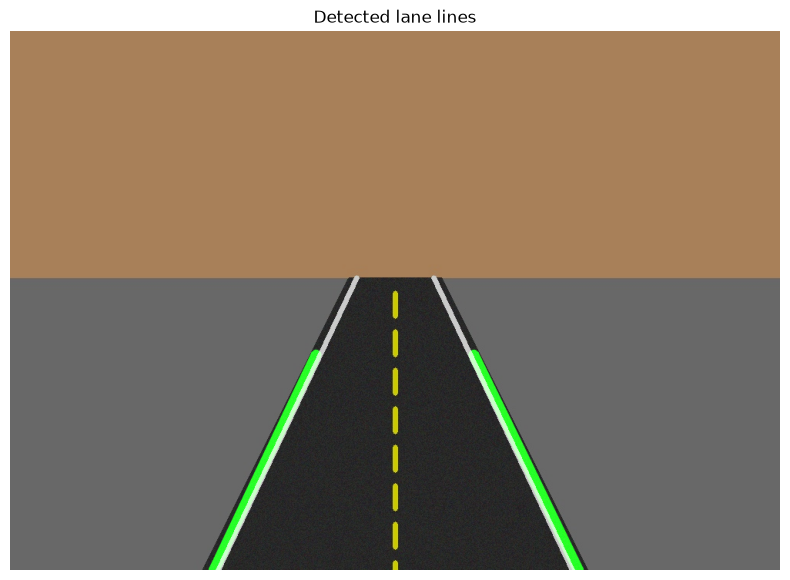

Left segments: 7
Right segments: 7


In [9]:
# ============================================================
# TASK 6: Lane Detection
# ============================================================

IMAGE_PATH = 'road.jpg'

img = cv.imread(
    IMAGE_PATH
)

if img is None:
    raise FileNotFoundError(
        f"Image not found: {IMAGE_PATH}"
    )

H, W = img.shape[:2]

gray = cv.cvtColor(
    img,
    cv.COLOR_BGR2GRAY
)

blur = cv.GaussianBlur(
    gray,
    (5, 5),
    0
)

edges = cv.Canny(
    blur,
    50,
    150
)

roi = np.array([
    [
        (0, H),
        (W, H),
        (int(0.60 * W), int(0.60 * H)),
        (int(0.40 * W), int(0.60 * H))
    ]
], dtype=np.int32)

mask = np.zeros_like(edges)

cv.fillPoly(
    mask,
    roi,
    255
)

roi_edges = cv.bitwise_and(
    edges,
    mask
)

lines = cv.HoughLinesP(
    roi_edges,
    1,
    np.pi / 180,
    threshold=45,
    minLineLength=40,
    maxLineGap=120
)

left = []
right = []

if lines is not None:

    lines = lines.reshape(-1, 4)

    for x1, y1, x2, y2 in lines:

        if x2 == x1:
            continue

        slope = (
            (y2 - y1)
            / float(x2 - x1)
        )

        if abs(slope) < 0.45:
            continue

        b = y1 - slope * x1

        if slope > 0:
            left.append(
                (slope, b)
            )

        else:
            right.append(
                (slope, b)
            )


def extrapolate(params):

    if not params:
        return None

    m, b = np.mean(
        params,
        axis=0
    )

    if abs(m) < 1e-6:
        return None

    y1 = H
    y2 = int(0.60 * H)

    x1 = int((y1 - b) / m)
    x2 = int((y2 - b) / m)

    return (
        x1,
        y1,
        x2,
        y2
    )


left_line = extrapolate(left)
right_line = extrapolate(right)

result = img.copy()
overlay = np.zeros_like(img)

for line in [
    left_line,
    right_line
]:

    if line is not None:

        cv.line(
            overlay,
            line[:2],
            line[2:],
            (0, 255, 0),
            12,
            cv.LINE_AA
        )

result = cv.addWeighted(
    result,
    0.8,
    overlay,
    1.0,
    0
)

show(
    roi_edges,
    'ROI Canny edges'
)

show(
    result,
    'Detected lane lines'
)

cv.imwrite(
    'task6_lane_detection.jpg',
    result
)

print(
    'Left segments:',
    len(left)
)

print(
    'Right segments:',
    len(right)
)


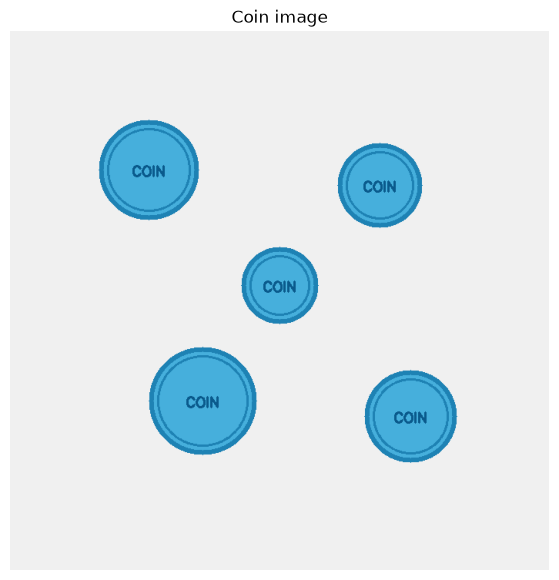

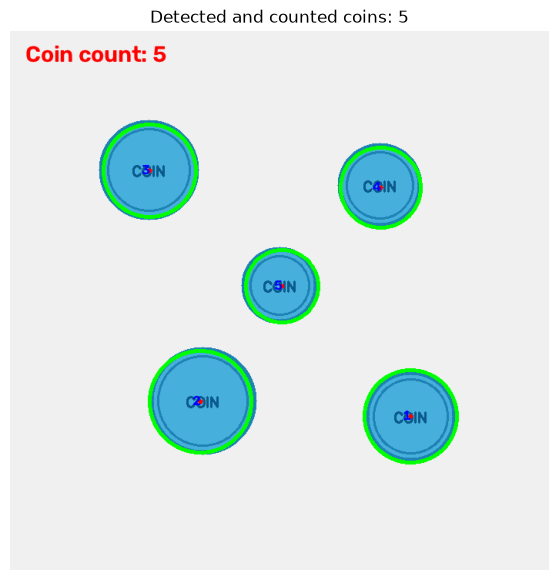

Total coins: 5


In [10]:
# ============================================================
# TASK 7: Coin Detection and Counting
# ============================================================

IMAGE_PATH = 'coin.png'

img = cv.imread(
    IMAGE_PATH
)

if img is None:
    raise FileNotFoundError(
        f"Image not found: {IMAGE_PATH}"
    )

gray = cv.cvtColor(
    img,
    cv.COLOR_BGR2GRAY
)

gray = cv.medianBlur(
    gray,
    7
)

show(
    img,
    'Coin image'
)

circles = cv.HoughCircles(
    gray,
    cv.HOUGH_GRADIENT,
    dp=1.2,
    minDist=35,
    param1=120,
    param2=30,
    minRadius=15,
    maxRadius=100
)

result = img.copy()
count = 0

if circles is not None:

    circles = np.uint16(
        np.around(circles[0])
    )

    count = len(circles)

    for i, (x, y, r) in enumerate(
        circles,
        start=1
    ):

        cv.circle(
            result,
            (x, y),
            r,
            (0, 255, 0),
            3
        )

        cv.circle(
            result,
            (x, y),
            3,
            (0, 0, 255),
            -1
        )

        cv.putText(
            result,
            str(i),
            (x - 10, y + 5),
            cv.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

cv.putText(
    result,
    f'Coin count: {count}',
    (20, 40),
    cv.FONT_HERSHEY_SIMPLEX,
    1,
    (0, 0, 255),
    3
)

show(
    result,
    f'Detected and counted coins: {count}'
)

cv.imwrite(
    'task7_coin_count.jpg',
    result
)

print(
    'Total coins:',
    count
)


In [11]:
# ============================================================
# TASK 8: Security Zone Monitoring
# ============================================================

VIDEO_PATH = 'security_video.mp4'
OUTPUT_PATH = 'task8_security_output.mp4'

cap = cv.VideoCapture(
    VIDEO_PATH
)

if not cap.isOpened():
    raise FileNotFoundError(
        f"Video not found: {VIDEO_PATH}"
    )

fps = cap.get(
    cv.CAP_PROP_FPS
) or 25

W = int(
    cap.get(
        cv.CAP_PROP_FRAME_WIDTH
    )
)

H = int(
    cap.get(
        cv.CAP_PROP_FRAME_HEIGHT
    )
)

out = cv.VideoWriter(
    OUTPUT_PATH,
    cv.VideoWriter_fourcc(*'mp4v'),
    fps,
    (W, H)
)

zx1 = int(0.30 * W)
zy1 = int(0.35 * H)
zx2 = int(0.72 * W)
zy2 = int(0.90 * H)

sub = cv.createBackgroundSubtractorMOG2(
    history=300,
    varThreshold=35,
    detectShadows=True
)

k = np.ones(
    (5, 5),
    np.uint8
)

alarm_frames = 0
frame_count = 0

try:

    while True:

        ok, frame = cap.read()

        if not ok:
            break

        frame_count += 1

        fg = sub.apply(frame)

        fg[fg == 127] = 0

        fg = cv.morphologyEx(
            fg,
            cv.MORPH_OPEN,
            k,
            iterations=1
        )

        fg = cv.morphologyEx(
            fg,
            cv.MORPH_CLOSE,
            k,
            iterations=2
        )

        contours, _ = cv.findContours(
            fg,
            cv.RETR_EXTERNAL,
            cv.CHAIN_APPROX_SIMPLE
        )

        alarm = False

        for c in contours:

            if cv.contourArea(c) < 1200:
                continue

            x, y, w, h = cv.boundingRect(c)

            ix = max(
                0,
                min(x + w, zx2)
                - max(x, zx1)
            )

            iy = max(
                0,
                min(y + h, zy2)
                - max(y, zy1)
            )

            if ix * iy > 0:

                alarm = True

                cv.rectangle(
                    frame,
                    (x, y),
                    (x + w, y + h),
                    (0, 0, 255),
                    3
                )

                cv.drawContours(
                    frame,
                    [c],
                    -1,
                    (0, 255, 255),
                    2
                )

        cv.rectangle(
            frame,
            (zx1, zy1),
            (zx2, zy2),
            (255, 0, 0),
            3
        )

        if alarm:

            alarm_frames += 1

            cv.putText(
                frame,
                'ALARM: UNAUTHORIZED OBJECT IN SECURITY ZONE',
                (20, 45),
                cv.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 0, 255),
                3
            )

        else:

            cv.putText(
                frame,
                'SECURITY ZONE CLEAR',
                (20, 45),
                cv.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 0),
                2
            )

        out.write(frame)

finally:

    cap.release()
    out.release()

print(
    f'Saved {OUTPUT_PATH}; '
    f'alarm active for '
    f'{alarm_frames}/{frame_count} frames'
)


Saved task8_security_output.mp4; alarm active for 51/90 frames
